In [2]:
import math, os, time
import meep as mp
import numpy as np
import matplotlib.pyplot as plt

os.environ["OMP_NUM_THREADS"] = "4"

# -------------------------------------
# Constants
# -------------------------------------
c0 = 299792458
um_scale = 1e-6

# -------------------------------------
# Materials
# -------------------------------------
sigma_meep = 0.000
gaas = mp.Medium(epsilon=12, D_conductivity=2 * math.pi * 1 * sigma_meep / 3.4)
air = mp.Medium(epsilon=1)

# -------------------------------------
# Geometry
# -------------------------------------
disk_radius = 3.5
wg_length = 20
wg_width = 0.22
gap = 0.1

cell_x = wg_length
cell_y = 2 * (disk_radius + gap + wg_width / 2) + 10
cell = mp.Vector3(cell_x, cell_y, 0)
pml_layers = [mp.PML(2.0)]
resolution = 32  # pixels/um

geometry = [
    mp.Cylinder(radius=disk_radius, height=mp.inf, center=mp.Vector3(0, 0), material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, disk_radius + gap + wg_width / 2),
             material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, -disk_radius - gap - wg_width / 2),
             material=gaas)
]

# -------------------------------------
# Sweep setup (input in THz)
# -------------------------------------
freqs_thz = np.linspace(322, 324, 200)  # THz sweep range
freqs_meep = freqs_thz * um_scale * 1e12 / c0

transmissions = []

# Define positions
src_pos = mp.Vector3(-wg_length/2 + 2, -disk_radius - gap - wg_width/2)   # left side of bottom waveguide
flux_pos = mp.Vector3(wg_length/2 - 2, -disk_radius - gap - wg_width/2)   # right side of bottom waveguide
flux_size = mp.Vector3(0, wg_width, 0)

# -------------------------------------
# Frequency sweep loop
# -------------------------------------
for i, (f_thz, f_meep) in enumerate(zip(freqs_thz, freqs_meep)):
    print(f"\nRunning {f_thz:.2f} THz ({i+1}/{len(freqs_thz)})")

    sim = mp.Simulation(
        cell_size=cell,
        geometry=geometry,
        boundary_layers=pml_layers,
        resolution=resolution,
        sources=[mp.Source(mp.ContinuousSource(frequency=f_meep),
                           component=mp.Ez,
                           center=src_pos)]
    )

    # Transmitted flux monitor
    trans_flux = sim.add_flux(f_meep, 0, 1, mp.FluxRegion(center=flux_pos, size=flux_size))

    # Run for several optical periods (steady-state)
    sim.run(until=200 / f_meep)   # adjust 100–300 periods depending on Q

    flux_val = mp.get_fluxes(trans_flux)[0]
    transmissions.append(flux_val)

# -------------------------------------
# Normalize and plot
# ------------------------------------
transmissions = np.array(transmissions)

plt.figure(figsize=(7,4))
plt.plot(freqs_thz, transmissions, 'o-', lw=1.5)
plt.xlabel("Frequency (THz)")
plt.ylabel("Transmission")
plt.title("Transmission spectrum — resonance dip")
plt.grid(True)
plt.show()



Running 322.00 THz (1/200)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000396935 s
Working in 2D dimensions.
Computational cell is 20 x 17.4062 x 0 with resolution 32
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 0.490203 s
-----------


FloatProgress(value=0.0, description='0% done ', max=186.20649565217394)

Meep progress: 25.984375/186.20649565217394 = 14.0% done in 4.0s, 24.7s to go
on time step 1665 (time=26.0156), 0.00240315 s/step
Meep progress: 53.34375/186.20649565217394 = 28.6% done in 8.0s, 19.9s to go
on time step 3416 (time=53.375), 0.00228446 s/step
Meep progress: 81.140625/186.20649565217394 = 43.6% done in 12.0s, 15.5s to go
on time step 5195 (time=81.1719), 0.00224941 s/step
Meep progress: 108.96875/186.20649565217394 = 58.5% done in 16.0s, 11.3s to go
on time step 6976 (time=109), 0.00224652 s/step
Meep progress: 136.65625/186.20649565217394 = 73.4% done in 20.0s, 7.3s to go
on time step 8749 (time=136.703), 0.00225723 s/step
Meep progress: 164.65625/186.20649565217394 = 88.4% done in 24.0s, 3.1s to go
on time step 10540 (time=164.688), 0.00223343 s/step


run 0 finished at t = 186.21875 (11918 timesteps)

Running 322.01 THz (2/200)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000345806 s
Working in 2D dimensions.
Computational cell is 20 x 17.4062 x 0 with resolution 32
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 0.727137 s
-----------


FloatProgress(value=0.0, description='0% done ', max=186.20068396379523)

...

Meep progress: 23.515625/185.70223227915082 = 12.7% done in 4.0s, 27.6s to go
on time step 1507 (time=23.5469), 0.00265437 s/step
Meep progress: 44.203125/185.70223227915082 = 23.8% done in 8.0s, 25.6s to go
on time step 2831 (time=44.2344), 0.00302198 s/step
Meep progress: 66.890625/185.70223227915082 = 36.0% done in 12.0s, 21.3s to go
on time step 4283 (time=66.9219), 0.00275527 s/step
Meep progress: 88.171875/185.70223227915082 = 47.5% done in 16.0s, 17.7s to go
on time step 5646 (time=88.2188), 0.00293607 s/step
Meep progress: 110.515625/185.70223227915082 = 59.5% done in 20.0s, 13.6s to go
on time step 7077 (time=110.578), 0.00279663 s/step
Meep progress: 132.4375/185.70223227915082 = 71.3% done in 24.0s, 9.7s to go
on time step 8480 (time=132.5), 0.00285265 s/step
Meep progress: 156.3125/185.70223227915082 = 84.2% done in 28.0s, 5.3s to go
on time step 10009 (time=156.391), 0.00261633 s/step
Meep progress: 181.015625/185.70223227915082 = 97.5% done in 32.0s, 0.8s to go
on time st

run 0 finished at t = 185.703125 (11885 timesteps)

Running 322.88 THz (89/200)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000309292 s
Working in 2D dimensions.
Computational cell is 20 x 17.4062 x 0 with resolution 32
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 0.717488 s
-----------


FloatProgress(value=0.0, description='0% done ', max=185.6964520247767)

Meep progress: 22.3125/185.6964520247767 = 12.0% done in 4.0s, 29.3s to go
on time step 1429 (time=22.3281), 0.00279964 s/step
Meep progress: 43.109375/185.6964520247767 = 23.2% done in 8.0s, 26.5s to go
on time step 2761 (time=43.1406), 0.00300416 s/step
Meep progress: 64.59375/185.6964520247767 = 34.8% done in 12.0s, 22.5s to go
on time step 4137 (time=64.6406), 0.0029086 s/step
Abort is in progress...hit ctrl-c again within 5 seconds to forcibly terminate



KeyboardInterrupt: 


[1/800] Running 322.000 THz ...
-----------
Initializing structure...
time for choose_chunkdivision = 0.000307406 s
Working in 2D dimensions.
Computational cell is 20 x 17.4167 x 0 with resolution 36
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)


time for set_epsilon = 0.649479 s
-----------


FloatProgress(value=0.0, description='0% done ', max=186.20649565217394)

Meep progress: 16.5/186.20649565217394 = 8.9% done in 4.0s, 41.2s to go
on time step 1189 (time=16.5139), 0.00336717 s/step
Meep progress: 32.55555555555556/186.20649565217394 = 17.5% done in 8.0s, 37.8s to go
on time step 2346 (time=32.5833), 0.00345781 s/step
Meep progress: 58.666666666666664/186.20649565217394 = 31.5% done in 12.0s, 26.1s to go
on time step 4228 (time=58.7222), 0.00212651 s/step
Meep progress: 84.94444444444444/186.20649565217394 = 45.6% done in 16.0s, 19.1s to go
on time step 6121 (time=85.0139), 0.00211398 s/step
Meep progress: 111.19444444444444/186.20649565217394 = 59.7% done in 20.0s, 13.5s to go
on time step 8011 (time=111.264), 0.00211647 s/step
Meep progress: 134.11111111111111/186.20649565217394 = 72.0% done in 24.0s, 9.3s to go
on time step 9661 (time=134.181), 0.0024248 s/step
Meep progress: 153.95833333333331/186.20649565217394 = 82.7% done in 28.0s, 5.9s to go
on time step 11090 (time=154.028), 0.00280034 s/step
Meep progress: 172.5/186.20649565217394 =

run 0 finished at t = 186.20833333333331 (13407 timesteps)
    Transmission = 2.834e+02, runtime = 35.7s

[2/800] Running 322.003 THz ...
-----------
Initializing structure...
time for choose_chunkdivision = 0.000547241 s
Working in 2D dimensions.
Computational cell is 20 x 17.4167 x 0 with resolution 36
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 0.819417 s
-----------


...

FloatProgress(value=0.0, description='0% done ', max=185.0585025471851)

Meep progress: 24.180555555555554/185.0585025471851 = 13.1% done in 4.0s, 26.6s to go
on time step 1742 (time=24.1944), 0.0022966 s/step
Meep progress: 49.263888888888886/185.0585025471851 = 26.6% done in 8.0s, 22.1s to go
on time step 3548 (time=49.2778), 0.00221513 s/step
Meep progress: 74.38888888888889/185.0585025471851 = 40.2% done in 12.0s, 17.9s to go
on time step 5357 (time=74.4028), 0.0022116 s/step
Meep progress: 99.45833333333333/185.0585025471851 = 53.7% done in 16.0s, 13.8s to go
on time step 7162 (time=99.4722), 0.00221652 s/step
Meep progress: 124.65277777777777/185.0585025471851 = 67.4% done in 20.0s, 9.7s to go
on time step 8976 (time=124.667), 0.00220553 s/step
Meep progress: 149.80555555555554/185.0585025471851 = 81.0% done in 24.0s, 5.6s to go
on time step 10787 (time=149.819), 0.00220907 s/step
Meep progress: 173.98611111111111/185.0585025471851 = 94.0% done in 28.0s, 1.8s to go
on time step 12528 (time=174), 0.00229754 s/step


run 0 finished at t = 185.06944444444443 (13325 timesteps)
    Transmission = 2.868e+02, runtime = 30.5s

[800/800] Running 324.000 THz ...
-----------
Initializing structure...
time for choose_chunkdivision = 0.0002686 s
Working in 2D dimensions.
Computational cell is 20 x 17.4167 x 0 with resolution 36
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 0.646187 s
-----------


FloatProgress(value=0.0, description='0% done ', max=185.0570728395062)

Meep progress: 23.61111111111111/185.0570728395062 = 12.8% done in 4.0s, 27.4s to go
on time step 1701 (time=23.625), 0.00235212 s/step
Meep progress: 48.72222222222222/185.0570728395062 = 26.3% done in 8.0s, 22.4s to go
on time step 3509 (time=48.7361), 0.0022124 s/step
Meep progress: 74.01388888888889/185.0570728395062 = 40.0% done in 12.0s, 18.0s to go
on time step 5330 (time=74.0278), 0.00219681 s/step
Meep progress: 99.20833333333333/185.0570728395062 = 53.6% done in 16.0s, 13.8s to go
on time step 7144 (time=99.2222), 0.00220559 s/step
Meep progress: 124.51388888888889/185.0570728395062 = 67.3% done in 20.0s, 9.7s to go
on time step 8967 (time=124.542), 0.00219534 s/step
Meep progress: 149.79166666666666/185.0570728395062 = 80.9% done in 24.0s, 5.7s to go
on time step 10787 (time=149.819), 0.00219793 s/step
Meep progress: 175.11111111111111/185.0570728395062 = 94.6% done in 28.0s, 1.6s to go
on time step 12610 (time=175.139), 0.00219441 s/step
run 0 finished at t = 185.0694444444

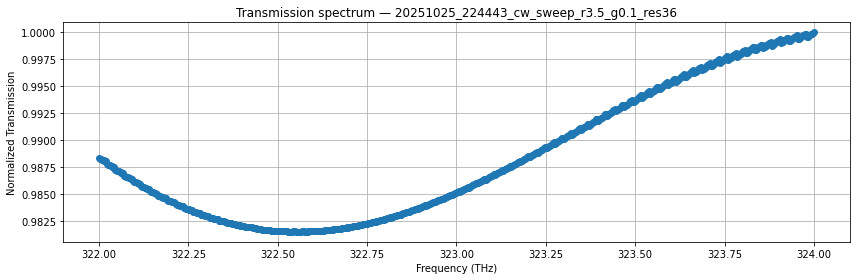


✅ Sweep complete.
Results saved to: data_cw/20251025_224443_cw_sweep_r3.5_g0.1_res36


In [6]:
import math, os, time
import meep as mp
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

os.environ["OMP_NUM_THREADS"] = "4"

# -------------------------------------
# Constants
# -------------------------------------
c0 = 299792458
um_scale = 1e-6

# -------------------------------------
# Materials
# -------------------------------------
sigma_meep = 0.000
gaas = mp.Medium(epsilon=12, D_conductivity=2 * math.pi * 1 * sigma_meep / 3.4)
air = mp.Medium(epsilon=1)

# -------------------------------------
# Geometry
# -------------------------------------
disk_radius = 3.5
wg_length = 20
wg_width = 0.22
gap = 0.1

cell_x = wg_length
cell_y = 2 * (disk_radius + gap + wg_width / 2) + 10
cell = mp.Vector3(cell_x, cell_y, 0)
pml_layers = [mp.PML(2.0)]
resolution = 36  # pixels/um

geometry = [
    mp.Cylinder(radius=disk_radius, height=mp.inf, center=mp.Vector3(0, 0), material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, disk_radius + gap + wg_width / 2),
             material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, -disk_radius - gap - wg_width / 2),
             material=gaas)
]

# -------------------------------------
# Frequency sweep setup (input in THz)
# -------------------------------------
freqs_thz = np.linspace(322, 324, 800)  # THz sweep range
freqs_meep = freqs_thz * um_scale * 1e12 / c0

transmissions = []

# Source and flux positions (bottom waveguide)
src_pos = mp.Vector3(-wg_length/2 + 2, -disk_radius - gap - wg_width/2)
flux_pos = mp.Vector3(wg_length/2 - 2, -disk_radius - gap - wg_width/2)
flux_size = mp.Vector3(0, wg_width, 0)

# -------------------------------------
# Output directory setup
# -------------------------------------
base_dir = "data_cw"
os.makedirs(base_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
folder_name = f"{timestamp}_cw_sweep_r{disk_radius}_g{gap}_res{resolution}"
run_dir = os.path.join(base_dir, folder_name)
os.makedirs(run_dir, exist_ok=True)

# -------------------------------------
# Frequency sweep loop
# -------------------------------------
t_total_start = time.time()

for i, (f_thz, f_meep) in enumerate(zip(freqs_thz, freqs_meep)):
    print(f"\n[{i+1}/{len(freqs_thz)}] Running {f_thz:.3f} THz ...")
    t_start = time.time()

    sim = mp.Simulation(
        cell_size=cell,
        geometry=geometry,
        boundary_layers=pml_layers,
        resolution=resolution,
        sources=[mp.Source(mp.ContinuousSource(frequency=f_meep),
                           component=mp.Ez,
                           center=src_pos)]
    )

    trans_flux = sim.add_flux(f_meep, 0, 1, mp.FluxRegion(center=flux_pos, size=flux_size))

    sim.run(until=200 / f_meep)  # ~300 optical periods

    flux_val = mp.get_fluxes(trans_flux)[0]
    transmissions.append(flux_val)

    print(f"    Transmission = {flux_val:.3e}, runtime = {time.time()-t_start:.1f}s")

t_total = time.time() - t_total_start

# -------------------------------------
# Normalize and plot
# -------------------------------------
transmissions = np.array(transmissions)
trans_norm = transmissions / np.max(transmissions)

plt.figure(figsize=(12, 4))
plt.plot(freqs_thz, trans_norm, 'o-', lw=1.5)
plt.xlabel("Frequency (THz)")
plt.ylabel("Normalized Transmission")
plt.title(f"Transmission spectrum — {folder_name}")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------
# Save results
# -------------------------------------
np.save(os.path.join(run_dir, "freqs_thz.npy"), freqs_thz)
np.save(os.path.join(run_dir, "transmission_raw.npy"), transmissions)
np.save(os.path.join(run_dir, "transmission_norm.npy"), trans_norm)

np.savetxt(os.path.join(run_dir, "spectrum.txt"),
           np.column_stack([freqs_thz, trans_norm]),
           header="Frequency (THz)\tNormalized Transmission")

params = {
    "disk_radius": disk_radius,
    "gap": gap,
    "wg_length": wg_length,
    "wg_width": wg_width,
    "resolution": resolution,
    "sigma_meep": sigma_meep,
    "freq_start_THz": freqs_thz[0],
    "freq_end_THz": freqs_thz[-1],
    "num_points": len(freqs_thz),
    "runtime_total_s": round(t_total, 2)
}

with open(os.path.join(run_dir, "params.txt"), "w") as f:
    for k, v in params.items():
        f.write(f"{k} = {v}\n")

print("\n✅ Sweep complete.")
print("Results saved to:", run_dir)
